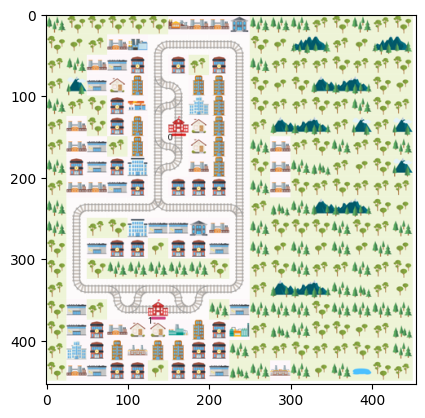

In [2]:
from flatland_tools.env import EnvGraph

import networkx as nx
import matplotlib.pyplot as plt
from flatland.envs.rail_env import RailEnv
from flatland.envs.rail_generators import sparse_rail_generator
from flatland.env           s.line_generators import sparse_line_generator
from itertools import product
import matplotlib.colors as mcolors
import matplotlib as mpl

cmap = mpl.colormaps["tab20"]

# Create the environment
rail_env = RailEnv(
    width=40,
    height=40,
    rail_generator=sparse_rail_generator(
        max_num_cities=4,
        grid_mode=True,
        max_rails_between_cities=2,
        max_rail_pairs_in_city=3,
        seed=43,
    ),
    line_generator=sparse_line_generator(),
    number_of_agents=2,
)

rail_env = RailEnv(
    width=18,
    height=18,
    rail_generator=sparse_rail_generator(
        max_num_cities=2,
        grid_mode=True,
        max_rails_between_cities=1,
        max_rail_pairs_in_city=1,
        seed=41,
    ),
    line_generator=sparse_line_generator(),
    number_of_agents=2,
)


rail_env.reset()
from flatland.utils.rendertools import AgentRenderVariant

plt.imshow(
    rail_env.render(agent_render_variant=AgentRenderVariant.BOX_ONLY, show_debug=True)
)

(array([], dtype=int64), array([], dtype=int64))
(array([], dtype=int64), array([], dtype=int64))


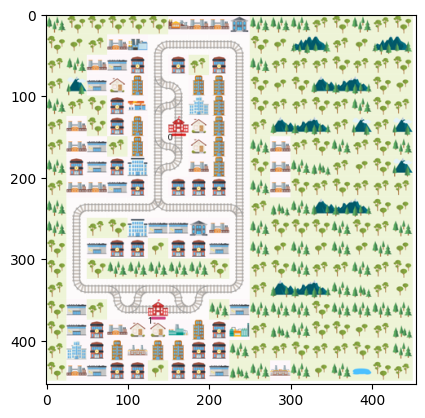

In [3]:
import numpy as np


actions = {}
print(np.where(rail_env.agent_positions >= 0))
for agent in rail_env.agents:
    actions[agent.handle] = 2
rail_env.step(actions)
print(np.where(rail_env.agent_positions >= 0))
plt.imshow(
    rail_env.render(agent_render_variant=AgentRenderVariant.BOX_ONLY, show_debug=True)
)

In [4]:
rail_env.agents

[EnvAgent(initial_position=(13, 5), initial_direction=<Grid4TransitionsEnum.EAST: 1>, direction=<Grid4TransitionsEnum.EAST: 1>, target=(5, 6), moving=False, earliest_departure=2, latest_arrival=30, waypoints=[Waypoint(position=(13, 5), direction=<Grid4TransitionsEnum.EAST: 1>), Waypoint(position=(5, 6), direction=None)], waypoints_earliest_departure=[2, None], waypoints_latest_arrival=[None, 30], handle=0, speed_counter=speed: 1.0                  max_speed: 1.0                  distance: 0                  is_cell_entry: True, action_saver=is_action_saved: False, saved_action: None, state_machine=
                   state: WAITING      previous_state WAITING 
                   st_signals: StateTransitionSignals(in_malfunction=False, earliest_departure_reached=False, stop_action_given=False, movement_action_given=True, target_reached=None, movement_allowed=False, new_speed=1.0), malfunction_handler=malfunction_down_counter: 0                 in_malfunction: False                 num_m

100%|██████████| 1296/1296 [00:00<00:00, 189977.21it/s]


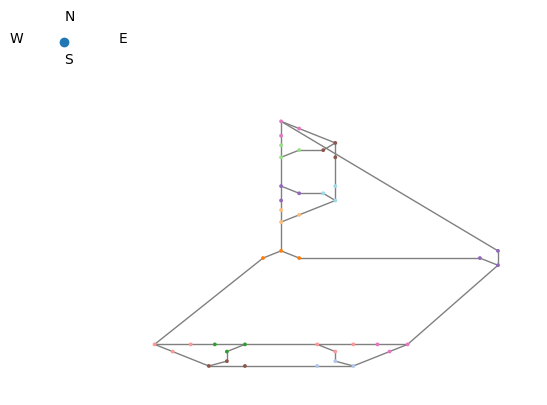

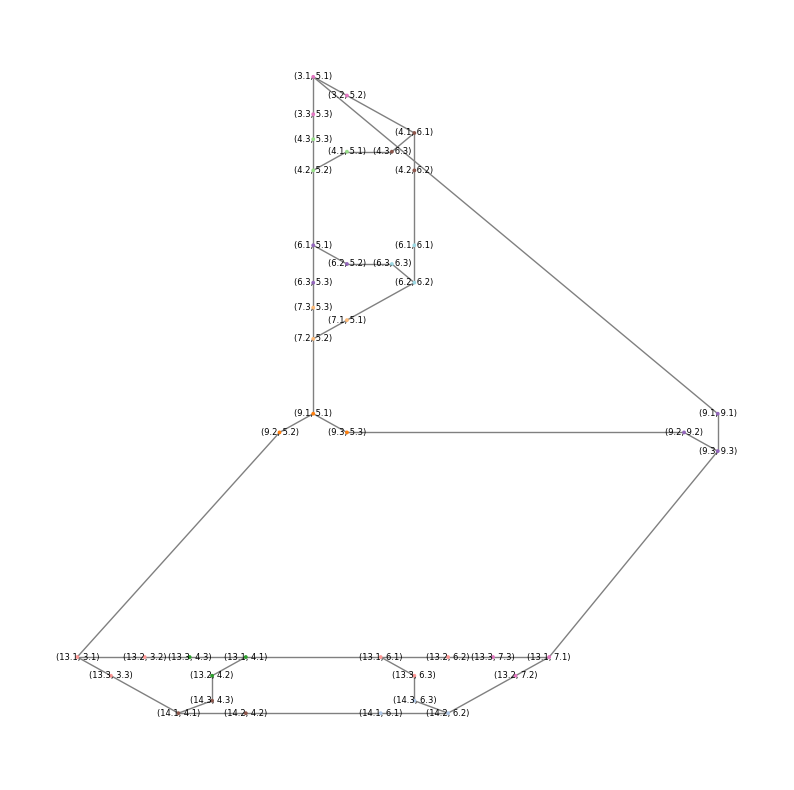

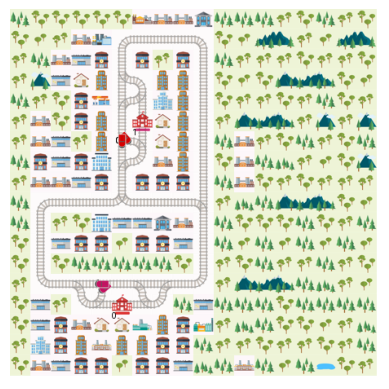

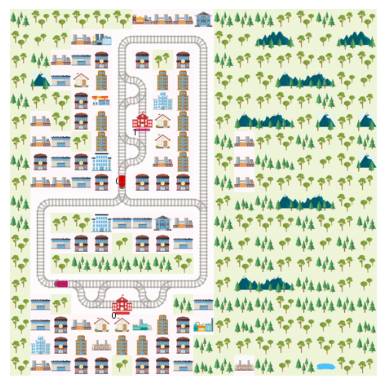

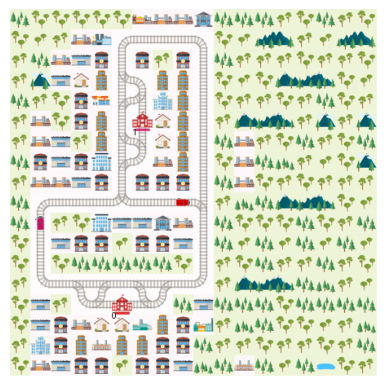

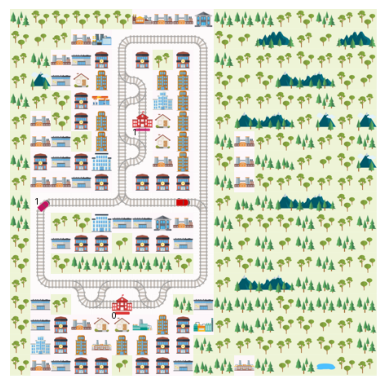

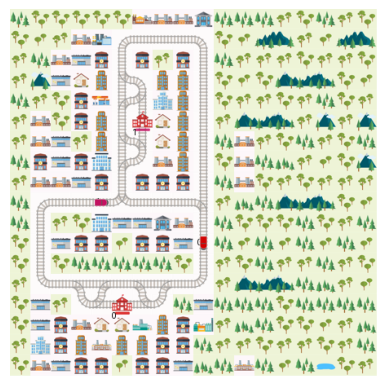

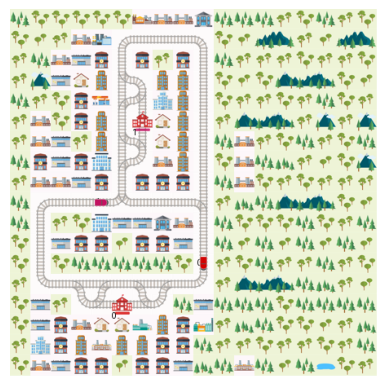

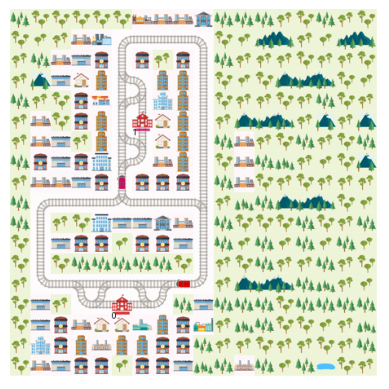

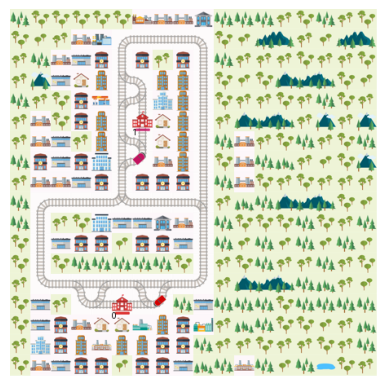

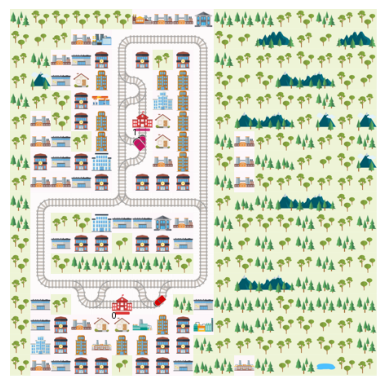

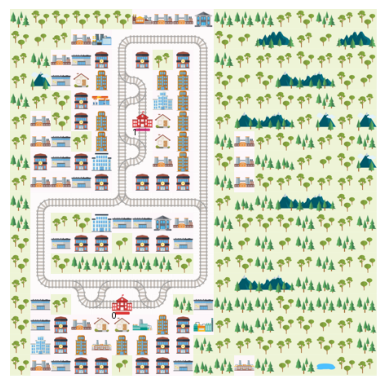

In [99]:
from collections import OrderedDict
import functools
from abc import ABC, abstractmethod
from itertools import product
from typing import Any, Callable, Dict, List, Literal, Tuple, Type

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from flatland.envs.line_generators import sparse_line_generator
from flatland.envs.rail_env import RailEnv, RailEnvActions
from flatland.envs.rail_generators import sparse_rail_generator
from flatland.envs.step_utils.env_utils import apply_action_independent
from flatland.utils.rendertools import AgentRenderVariant
from flatland.envs.agent_utils import EnvAgent as TrainAgent
from gymnasium import Space, spaces
from pettingzoo import AECEnv
import logging


from environment.utils import (
    create_rail_graph,
    generate_local_switch_graphs,
    insert_switch_proximity_nodes,
    prune_non_switches,
)


class DiscreteSwitchObsSpace(Space):
    def __init__(
        self, n_gaits: int, n_stations: int, n_delay_levels: int = 3, seed=None
    ):
        n_dims = n_gaits + (n_stations + 1) + (n_delay_levels + 1)
        shape = (n_dims,)
        dtype = int
        super().__init__(shape, dtype, seed)

        self.n_gaits = n_gaits  # how many rails are connected to a node -> Binary variable: is one occupied or not
        self.n_stations = (
            n_stations  # where a train would like to end up. No train -> -1
        )
        self.n_delay_levels = (
            n_delay_levels  # how strong the train is delayed. No train -> -1
        )

        self.station_space = spaces.MultiDiscrete(
            np.ones(self.n_gaits) * (self.n_stations + 1),
            seed=seed,
            start=np.ones(self.n_gaits) * (-1),
        )
        self.delay_space = spaces.MultiDiscrete(
            np.ones(self.n_gaits) * (self.n_delay_levels + 1),
            seed=seed,
            start=np.ones(self.n_gaits) * (-1),
        )
        # of a rail is blocked or if a train can be send onto this rail
        self.occupied_gait = spaces.MultiDiscrete(
            np.ones(n_gaits) * 2,
            seed=seed,
            start=np.zeros(n_gaits),
        )

    def sample(self):
        sample = np.concatenate(
            [
                self.occupied_gait.sample(),
                self.station_space.sample(),
                self.delay_space.sample(),
            ]
        )
        return sample

    @property
    def is_np_flattenable(self) -> bool:
        """Checks whether this space can be flattened to a :class:`gymnasium.spaces.Box`."""
        return True


def add_rail_actions(graph: nx.Graph) -> nx.Graph:
    """adds actions to each node.
    Each action annotation is stored at the 'action' datafield as a dictionary:
        - key: where the action leads to
        - value: action sequence

    Example:
    >>> switch_graph = add_rail_actions(switch_graph)
    >>> switch_graph.nodes.data('actions')[<source-node>][<target-node>]

    Args:
        graph (nx.Graph): switch graph without actions

    Returns:
        nx.Graph: switch graph with actions
    """
    actions = {}

    for i, incoming in enumerate(graph.nodes):
        facing_index = (i + 2) % 4  # Opposite direction (facing)
        actions[incoming] = {"actions": {}}  # graph.nodes.data()[incoming]
        for j, target in enumerate(graph.nodes):
            if incoming == target or target not in graph.neighbors(incoming):
                continue  # Cannot go back to where you came from
            relative = (j - facing_index) % 4
            action = [RailEnvActions.MOVE_FORWARD]  # enter switch
            if relative == 0:
                action.append(RailEnvActions.MOVE_FORWARD)
            elif relative == 1:
                action.append(RailEnvActions.MOVE_RIGHT)
            elif relative == 3:
                action.append(RailEnvActions.MOVE_LEFT)
            else:
                action = "invalid"  # Shouldn't occur
            actions[incoming]["actions"][target] = action

    nx.set_node_attributes(G=graph, values=actions)
    return graph


def build_rail_action_map(
    graph: nx.Graph,
) -> Tuple[List[Dict[Any, List[RailEnvActions]]], List[Tuple[Any, Any]]]:
    """computes which discrete environment actions result in which environment actions

    Args:
        graph (nx.Graph): switch graph with actions annotation:
            Each action annotation is stored at the 'action' datafield as a dictionary:
                - key: where the action leads to
                - value: action sequence


    Returns:
        Tuple[List[Dict[Any, List[RailEnvActions]]], List[Any, Any]]: Each entry in the parent list corresponds to one action
            1. List[Dict[Any, List[RailEnvActions]]]: each entry contains commands for trains at each port of the switch
            2. List[Any, Any]: After executing, across which ports will the train transition the switch (source, target)
    """
    actions = []
    target_map = []
    for node, port_actions in graph.nodes.data("actions"):
        for target, a in port_actions.items():
            action = {node: a}
            target_map.append((node, target))

            # add default stop action for all other nodes
            for other_node in graph.nodes:
                if other_node == node:
                    continue
                action[other_node] = [
                    RailEnvActions.STOP_MOVING,
                    RailEnvActions.STOP_MOVING,
                ]

            actions.append(action)
    return actions, target_map


class _SwitchAgent(ABC):
    # for the inner representation of an agent

    entity: int
    """what kind of switch are you"""
    n_gaits: int
    """how many rails are connected to the switch"""
    n_rails: int
    """amount of inner connections"""

    def __init__(
        self,
        switch_graph: nx.Graph,
        n_stations: int,
        n_delay_levels: int = 3,
        id: Any = None,
    ):
        super().__init__()
        self.switch_graph = switch_graph
        self.n_stations = n_stations
        self.n_delay_levels = n_delay_levels
        self.id = id
        if self.id is None:
            self.id = list(self.switch_graph.nodes.data("switch_id"))[0][1]

        self.switch_nodes = [
            node for node in self.switch_graph if self.switch_graph.degree(node) == 2
        ]
        self.non_switch_nodes = [
            node for node in self.switch_graph if self.switch_graph.degree(node) == 1
        ]
        self.semaphores = {n: False for n in self.switch_graph.nodes}

        self.action_map, self.outcomes = self._build_switch_rail_actions(
            self.switch_graph
        )

        assert len(self.action_map) == self.get_action_space().n

    def __repr__(self):
        id = self.id
        n_gaits = len(self.switch_graph.nodes)
        n_rails = len(self.switch_graph.edges)
        return f"Switch({id=}, {n_gaits=}, {n_rails=})"

    @classmethod
    def from_switch_graph(
        cls,
        switch_graph: nx.Graph,
        n_stations: int,
        n_delay_levels: int = 3,
        id: Any = None,
    ) -> "_SwitchAgent":
        n_gaits = len(switch_graph.nodes)
        n_rails = len(switch_graph.edges)
        cls = get_agent_abstraction(n_gaits, n_rails)
        return cls(switch_graph, n_stations, n_delay_levels, id=id)

    def get_train_action(
        self, action: int, train_agents: List[TrainAgent]
    ) -> Dict[int, List[RailEnvActions]]:
        res = {}
        for train_agent in train_agents:
            port_node = self._get_port_node_on_position(train_agent.position)
            if port_node is None:
                # train is not at a port node
                continue

            if self.semaphores[self.outcomes[action][1]]:
                raise RuntimeError(
                    f"Semaphore is blocked. Action with transition: {self.outcomes[action]} is not available"
                )
            res[train_agent.handle] = self.action_map[action][port_node]

        # NOTE: if the train is the only train at the switch:
        # just one waiting block -> otherwise we clog up the train_action_plan
        if len(res) == 1 and list(res.values())[0][0] == RailEnvActions.STOP_MOVING:
            res[list(res.keys())[0]] = [RailEnvActions.STOP_MOVING]

        return res

    
    def map_train_to_port(self, trains: List[TrainAgent]) -> Dict[Any, TrainAgent | None]:
        res = {node: None for node in self.switch_graph.nodes}
        for train in trains:
            port = self._get_port_node_on_position(train.position)
            if port is None:
                continue
            res[port] = train   
        return res
                
    def block_port(self, port: Any):
        if port not in self.semaphores.keys():
            print(f"{port=} is not part of switch:{self.id}")
            return
        self.semaphores[port] = True

    def free_port(self, port: Any):
        if port not in self.semaphores.keys():
            print(f"{port=} is not part of switch:{self.id}")
            return
        self.semaphores[port] = False

    def get_action_mask(self) -> np.ndarray:
        """which actions are allowed wrt. incoming train semaphores

        Returns:
            np.ndarray: integer array. 1: action allowed, 0: action forbidden (n_actions, )
        """
        mask = [self.semaphores[target] for _, target in self.outcomes]
        mask = (~np.array(mask)).astype(np.int8)
        return mask

    def get_observation_space(self, seed: int = None):
        return DiscreteSwitchObsSpace(
            self.n_gaits, self.n_stations, self.n_delay_levels, seed=seed
        )

    @abstractmethod
    def get_action_space(self, seed: int = None):
        raise NotImplementedError

    @staticmethod
    def _build_switch_rail_actions(
        switch_graph: nx.Graph,
    ) -> List[Dict[Any, List[RailEnvActions]]]:
        """returns a list of actions for each port.

        Args:
            switch_graph (nx.Graph): switch graph with ports and inter-connectivity's

        Returns:
            List[Dict[Any, List[RailEnvActions]]]: each element in the list is a collection of actions for each port:
                Each dictionary: key=port(node)-identifier, value=Sequence of actions(enter switch leave switch)
        """
        # add actions to switch_graph
        switch_graph = add_rail_actions(switch_graph)
        action_map = build_rail_action_map(switch_graph)
        return action_map

    def _get_port_node_on_position(
        self, position: Tuple[int, int]
    ) -> Tuple[float, float] | None:
        for node in self.switch_graph.nodes:
            if self.switch_graph.nodes.data(data="rail_prev_node")[node] == position:
                return node
        return None


# T or Y junction
class SwitchAgent1(_SwitchAgent):
    def __init__(self, switch_graph, n_stations, n_delay_levels=3, id=None):
        super().__init__(switch_graph, n_stations, n_delay_levels, id)
        self.entity = 1
        self.n_gaits = 3
        self.n_rails = 2

    def get_action_space(self, seed: int = None):
        # gaits: 0, 1, 2
        # switch gait: 3
        # 0  1  2
        # --------
        # g  w  w
        # w  g  w
        # w  w  g1
        # w  w  g2
        # can have a different permutation based on orientation
        return spaces.Discrete(4, seed=seed)

    @property
    def switch_node(self):
        # only one switch node
        return self.switch_nodes[0]


# Intersection
class SwitchAgent2(_SwitchAgent):
    def __init__(self, id, position, n_stations, switch_ports=None, n_delay_levels=3):
        super().__init__(id, position, n_stations, switch_ports, n_delay_levels)
        self.entity = 2
        self.n_gaits = 4
        self.n_rails = 2

    def get_action_space(self, seed=None):
        # gaits: 0, 1, 2, 3
        # switch gait: None
        # 0  1  2  3
        # ----------
        # g  w  g  w
        # w  g  w  g
        return spaces.Discrete(2, seed=seed)


# Intersection with one pass
class SwitchAgent3(_SwitchAgent):
    def __init__(self, id, position, n_stations, switch_ports=None, n_delay_levels=3):
        super().__init__(id, position, n_stations, switch_ports, n_delay_levels)
        self.entity = 3
        self.n_gaits = 4
        self.n_rails = 3

    def get_action_space(self, seed=None):
        # gaits: 0, 1, 2, 3
        # switch gait: 0, 3
        # 0  1  2  3
        # ----------
        # g1 w  w  w
        # g2 w  w  w
        # w  g  w  w
        # w  w  g  w
        # w  w  w  g1
        # w  w  w  g2
        return spaces.Discrete(6, seed=seed)


# Intersection with two passes
class SwitchAgent4(_SwitchAgent):
    def __init__(self, id, position, n_stations, switch_ports=None, n_delay_levels=3):
        super().__init__(id, position, n_stations, switch_ports, n_delay_levels)
        self.entity = 4
        self.n_gaits = 4
        self.n_rails = 4

    def get_action_space(self, seed=None):
        # gaits: 0, 1, 2, 3
        # switch gait: 0, 1, 2, 3
        # 0  1  2  3
        # ----------
        # g1 w  w  w
        # g2 w  w  w
        # w  g1 w  w
        # w  g2 w  w
        # w  w  g1 w
        # w  w  g2 w
        # w  w  w  g1
        # w  w  w  g2
        return spaces.Discrete(8, seed=seed)


def get_agent_abstraction(n_gaits: int, n_rails: int) -> Type[_SwitchAgent]:
    if n_gaits == 3:
        return SwitchAgent1
    elif n_gaits > 4:
        raise ValueError("No agent type with more than 4 rails")

    if n_rails == 2:
        return SwitchAgent2
    elif n_rails == 3:
        return SwitchAgent3
    elif n_rails == 4:
        return SwitchAgent4
    else:
        raise ValueError(f"No Agent with {n_gaits=} and {n_rails=}")


def get_switch_id(identifier: Any) -> str:
    return f"switch_{identifier}"


class SwitchEnv(AECEnv):
    def __init__(self, rail_env: RailEnv, max_steps: int = 200, seed: int = None):
        super().__init__()
        self.rail_env = rail_env
        self.rail_env.reset()


        self.max_steps = max_steps
        self.seed = seed

        self.switch_network_graph = self._create_switch_graph(self.rail_env)

        pos = self.switch_network_graph.nodes.data(data="pos")
        pos = {k: v for k, v in pos}

        fig, ax = plt.subplots()
        ax.scatter(1, 1)
        ax.text(1, 2, "N")
        ax.text(1, 0, "S")
        ax.text(2, 1, "E")
        ax.text(0, 1, "W")
        nx.draw(
            self.switch_network_graph,
            pos,
            # connectionstyle="arc3,rad=0.1",
            with_labels=False,
            node_color=dict(
                self.switch_network_graph.nodes.data(data="node_color")
            ).values(),
            edge_color="gray",
            node_size=3,
            # arrowsize=3
            ax=ax,
        )

        self._node_df = self.get_node_df(self.switch_network_graph)

        # switch agents
        self.possible_agents = [
            get_switch_id(idx) for idx in self._node_df["switch_id"].unique()
        ]
        # all active switch agents
        self.agents = []

        self.train_action_plan = {k.handle: [] for k in self.rail_env.agents}
        self.terminations = {k: False for k in self.possible_agents}
        self.truncations = {k: False for k in self.possible_agents}
        self.rewards = {k: 0 for k in self.possible_agents}
        self._cumulative_rewards = {k: 0 for k in self.possible_agents}
        self.infos = {k: {} for k in self.possible_agents}
        self.step_counter = {k: 0 for k in self.possible_agents}
        self.terminated = False
        self.truncated = False

        self.train_obs = {train.handle: None for train in self.rail_env.agents}
        self.train_reward = {train.handle: 0 for train in self.rail_env.agents}
        self.train_done = {train.handle: False for train in self.rail_env.agents}
        self.train_info = {train.handle: None for train in self.rail_env.agents}
        self.train_targets = {train.target: idx for idx, train in enumerate(self.rail_env.agents)}

        self.switch_agents = self.build_agent_abstraction(
            self._node_df, self.possible_agents
        )
        self.observation_spaces = self.build_observation_spaces(seed=self.seed)
        self.action_spaces = self.build_action_spaces(seed=self.seed)

        # faster than the pandas DataFrame
        self._switch_signal_map = dict(
            zip(self._node_df["rail_prev_node"], self._node_df.index)
        )
        self._switch_id_switch_pos_map = dict(
            zip(self._node_df.index, self._node_df["switch_pos"])
        )

    def build_agent_abstraction(
        self, node_df: pd.DataFrame, agent_ids: List[str]
    ) -> Dict[str, _SwitchAgent]:
        agents = {}
        for switch_id, group in node_df.groupby("switch_id"):
            subgraph = self.switch_network_graph.subgraph(group.index)
            switch_agent = _SwitchAgent.from_switch_graph(
                subgraph, self.rail_env.rail_generator.max_num_cities
            )
            agents[get_switch_id(switch_id)] = switch_agent
        return agents

    def build_observation_spaces(self, seed: int = None) -> Dict[str, spaces.Space]:
        obs_spaces = {}
        for agent_id, agent in self.switch_agents.items():
            agent: _SwitchAgent
            obs_spaces[agent_id] = agent.get_observation_space(seed)
        return obs_spaces

    def build_action_spaces(self, seed: int = None) -> Dict[str, spaces.Space]:
        act_spaces = {}
        for agent_id, agent in self.switch_agents.items():
            agent: _SwitchAgent
            act_spaces[agent_id] = agent.get_action_space(seed)
        return act_spaces

    @functools.lru_cache(maxsize=None)
    def observation_space(self, agent):
        return self.observation_spaces[agent]

    @functools.lru_cache(maxsize=None)
    def action_space(self, agent):
        return self.action_spaces[agent]

    def get_node_df(self, graph: nx.Graph) -> pd.DataFrame:
        df = pd.DataFrame(
            [attr for _, attr in graph.nodes.data()],
            index=[idx for idx, _ in graph.nodes.data()],
        )
        # build intra node_df
        df["intra_switch_index"] = df.index.to_series().apply(lambda x: int(str(x[0])[-1]))
        
        return df

    def _create_switch_graph(self, env: RailEnv) -> nx.Graph:
        graph = create_rail_graph(env)
        graph = insert_switch_proximity_nodes(graph)
        graph = prune_non_switches(graph)
        graph = generate_local_switch_graphs(graph)
        return graph

    def _build_semaphores(self):
        """executed in reset()

        finds all train positions and setups all semaphores for all switches.

        Assume:
        - all trains are already on the grid
        - at least one train is in front of a switch
        """

        for train in self.rail_env.agents:
            # simulate steps of a train until they arrive at a switch
            # NOTE: yes this is expensive, but only executed once in reset()
            current_pos = train.position
            current_dir = train.direction
            while True:
                if sum(self._node_df["switch_pos"] == current_pos):
                    # train on switch
                    break
                last_pos = current_pos
                current_pos, current_dir = apply_action_independent(
                    RailEnvActions.MOVE_FORWARD,
                    self.rail_env.rail,
                    current_pos,
                    current_dir,
                )
            # last pos corresponds to rail_prev_node
            switch_id = self._node_df[
                (self._node_df["rail_prev_node"] == last_pos)
                & (self._node_df["switch_pos"] == current_pos)
            ]["switch_id"]
            self.switch_agents[get_switch_id(switch_id.item())].semaphores[
                switch_id.index.item()
            ] = True

    def _compute_delay(self, train: TrainAgent):
        """
        Returns the delay of the given train
        
        Args:
            train_id (int): The id of the train

        Returns:
            int: The delay of the given train
        """
        row, col = train.position if train.position is not None else train.initial_position
        min_dist_to_target = self.rail_env.distance_map.get()[train.handle, row, col, train.direction]
        # assume you are moving with max speed=1
        return self.rail_env._elapsed_steps - train.latest_arrival + min_dist_to_target

    def _discretize_delay(self, train: TrainAgent, delay: int) -> int:
        """
        Discretizes the delay of the given train
        
        Args:
            train_id (TrainAgent): The id of the train
            delay (int): The delay of the train
            
        Returns:
            int: The discretized delay of the given train
        """
        available_time = train.latest_arrival - train.earliest_departure
        if delay <= 0:
            return 0
        if delay <= available_time * self.delay_threshold:
            return 1
        return 2

    def move_trains(self, action: Dict[int, RailEnvActions] = None):
        base_action = {
            k.handle: RailEnvActions.MOVE_FORWARD for k in self.rail_env.agents
        }

        for train_agent_handle in base_action.keys():
            if len(self.train_action_plan[train_agent_handle]) == 0 or (
                action is not None and train_agent_handle in action.keys()
            ):  # manual overwrite
                continue
            base_action[train_agent_handle] = self.train_action_plan[
                train_agent_handle
            ].pop(0)

        # overwrite with custom action but always reduce train_action_plan
        if action is None:
            action = base_action
        else:
            base_action.update(action)
            action = base_action
            
        # check for done trains and remove actions for it
        for train in self.rail_env.agents:
            if self.train_done[train.handle]:
                action.pop(train.handle)
            
        # do rail env step
        self.train_obs, self.train_reward, self.train_done, self.train_info = (
            self.rail_env.step(action)
        )
        
        # check for all trains being done
        if self.train_done["__all__"]:
            self.terminations = {switch_agent: True for switch_agent in self.terminations.keys()}
            self.terminated = True

    def _check_active_switch(self):
        # do simulation step and see if a train enters a switch node -> then add the switch to active agents
        for train in self.rail_env.agents:
            if train.position is None:
                continue

            # get next action
            if len(self.train_action_plan[train.handle]) > 0:
                next_action = self.train_action_plan[train.handle][0]
            else:
                next_action = RailEnvActions.MOVE_FORWARD

            # do a simulation step an get the next switch if needed
            new_pos, _ = apply_action_independent(
                next_action,
                self.rail_env.rail,
                train.position,
                train.direction,
            )

            if (self._node_df["switch_pos"] == new_pos).sum():
                switch_id = get_switch_id(new_pos)
                self.agents.append(switch_id)

    def move_trains_to_switch(self):

        # Check active switch (0)
        # Loop:
        #     time t
        #     Train step (t)
        #     Check active switch (t+1)
        #
        # compute switch action (t)
        # perform action (t)

        # self._check_active_switch()

        while len(self.agents) == 0 and not self.terminated:
            # NOTE: after resetting the environment all trains are in a standstill
            # -> they have to be moved first after the reset
            self.move_trains()

            # move trains until they arrive on the grid
            current_positions = [train.position for train in self.rail_env.agents]
            current_positions = list(filter(lambda x: x is not None, current_positions))
            if len(current_positions) == 0:
                continue

            self._check_active_switch()

        # remove duplicates in agents but maintaining order
        self.agents = list(OrderedDict.fromkeys(self.agents))

    def apply_action(self, switch: _SwitchAgent, action: int):
        logging.debug("______")
        logging.debug(f"{action=}")
        rail_env_actions = switch.get_train_action(action, self.rail_env.agents)
        logging.debug(rail_env_actions)
        # transition rail network graph

        # 1. free semaphore on current switch
        source, target = switch.outcomes[action]
        logging.debug(source, target)
        logging.debug(switch.semaphores)
        switch.free_port(source)
        # 2. find next switch (account for simple intersection)
        neighbors = self.switch_network_graph.neighbors(target)
        next_switch = self._node_df[
            self._node_df.index.isin(neighbors)
            & (self._node_df["switch_id"] != switch.id)
        ]
        next_switch_id = get_switch_id(next_switch["switch_id"].item())
        # 3. activate semaphore on next switch
        port = next_switch.index.item()
        self.switch_agents[next_switch_id].block_port(port)
        logging.debug(self.switch_agents[next_switch_id].semaphores)

        # update train_action_plan such that _do_rail_env step can work it down
        for train_agent_handle in rail_env_actions.keys():
            self.train_action_plan[train_agent_handle].extend(
                rail_env_actions[train_agent_handle]
            )
        logging.debug(self.train_action_plan)

    def agent_iter(self, max_iter=2**63):
        while not (self.terminated or self.truncated):
            self.agent_selection = self.agents.pop(0)
            yield self.agent_selection

    def reset(self, seed=None, options=None):
        if options is None:
            options = {}
        self.rail_env.reset(random_seed=seed, **options)
        self.move_trains_to_switch()
        self._build_semaphores()

        self.rewards = {agent: 0 for agent in self.possible_agents}
        self._cumulative_rewards = {agent: 0 for agent in self.possible_agents}
        self.terminations = {agent: False for agent in self.possible_agents}
        self.truncations = {agent: False for agent in self.possible_agents}
        self.infos = {agent: {} for agent in self.possible_agents}
        self.observations = {agent: None for agent in self.possible_agents}
        
        self.num_moves = 0
        self.terminated = False
        self.truncated = False

    def step(self, action):
        self.apply_action(self.switch_agents[self.agent_selection], action)
        if len(self.agents) == 0:
            self.move_trains_to_switch()
            plt.imshow(self.render())
            plt.axis("off")
            plt.show()

        self.step_counter[self.agent_selection] += 1
        if self.n_steps > self.max_steps:
            self.truncations = {switch_agent: True for switch_agent in self.truncations.keys()}
            self.truncated = True

    def observe(self, agent):
        # get current observation
        
        # sort switch nodes according to first decimal -> use node_df
        switch_id = tuple(map(lambda x: int(x), agent.split("_")[1].strip("()").split(", ")))
        df = self._node_df[self._node_df["switch_id"] == switch_id]["intra_switch_index"]
        df = df.reset_index(0).set_index("intra_switch_index")
        
        semaphore = []
        target = []
        delay = []
        train_at_ports = self.switch_agents[agent].map_train_to_port(self.rail_env.agents)
        for node in df["index"]:
            semaphore.append(self.switch_agents[agent].semaphores[node])
            
            train = train_at_ports[node]
            if train is None:
                delay.append(-1)
                target.append(-1)
            else:
                delay.append(self._discretize_delay(train, self._compute_delay(train)))
                target.append(self.train_targets[train.target])
        semaphore = np.array(semaphore).astype(int)
        target = np.array(target).astype(int)
        delay = np.array(delay).astype(int)
        self.observations[agent] = np.concatenate([semaphore, delay, target])
        self.rewards[agent] = 0  # TODO: still open issue
        self.infos[agent].update(
            {"action_mask": self.switch_agents[agent].get_action_mask()}
        )

    def render(self):
        return self.rail_env.render(
            agent_render_variant=AgentRenderVariant.AGENT_SHOWS_OPTIONS, show_debug=True
        )

    def close(self):
        return super().close()

    @property
    def n_steps(self) -> int:
        """accumulated steps from each agents

        Returns:
            int: _description_
        """
        return sum(self.step_counter.values())


np.random.seed(1)

rail_env = RailEnv(
    width=18,
    height=18,
    rail_generator=sparse_rail_generator(
        max_num_cities=2,
        grid_mode=True,
        max_rails_between_cities=1,
        max_rail_pairs_in_city=1,
        seed=41,
    ),
    line_generator=sparse_line_generator(),
    number_of_agents=2,
)


env = SwitchEnv(rail_env)
env.reset(seed=42)
# plt.imshow(
#     rail_env.render(agent_render_variant=AgentRenderVariant.BOX_ONLY, show_debug=True)
# )
# plt.imshow(env.render())

fig, ax = plt.subplots(figsize=(10, 10))
nx.draw(
    env.switch_network_graph.to_undirected(),
    env._node_df["pos"],
    with_labels=True,
    node_color=dict(env.switch_network_graph.nodes.data(data="node_color")).values(),
    edge_color="gray",
    node_size=3,
    font_size=6,
    ax=ax,
)
plt.show()

for agent in env.agent_iter():
    observation, reward, termination, truncation, info = env.last()
    if termination or truncation:
        action = None
    else:
        # this is where you would insert your policy
        action = env.action_space(agent).sample(info["action_mask"])
    env.step(action)
    if env.n_steps > 20:
        break
env.close()

In [5]:
np.zeros(2).tolist()

[0.0, 0.0]

In [ ]:
%timeit new_pos, _ = apply_action_independent(RailEnvActions.MOVE_FORWARD, rail_env.rail, (5, 5), 2)

276 ns ± 6.16 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)


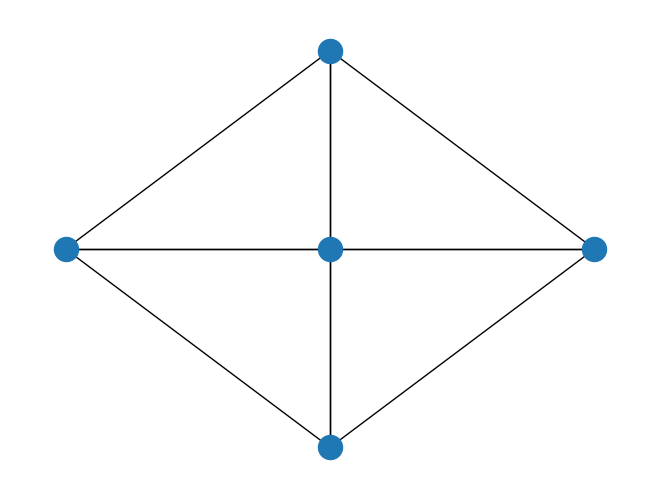

In [ ]:
# create complete graph on 5 nodes
import networkx as nx

pos = [[0, 0], [1, 0], [0, 1], [-1, 0], [0, -1]]
g = nx.complete_graph(5)
nx.draw(g, pos)

100%|██████████| 1296/1296 [00:00<00:00, 85377.55it/s]


{'node_color': '#2ca02c',
 'pos': [5.0, -2.6666666666666665],
 'switch_id': (3, 5),
 'switch_pos': (3, 5),
 'rail_prev_node': (2, 5)}

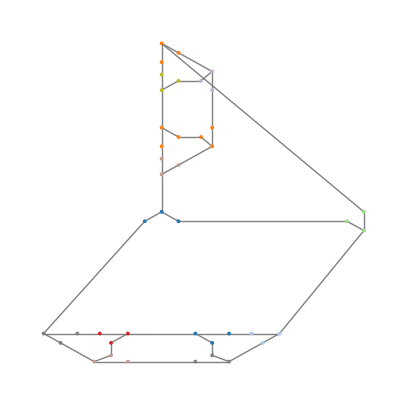

In [ ]:
switch_network_graph = create_rail_graph(rail_env)
switch_network_graph = insert_switch_proximity_nodes(switch_network_graph)
switch_network_graph = prune_non_switches(switch_network_graph)
switch_network_graph = generate_local_switch_graphs(switch_network_graph)

fig, ax = plt.subplots(figsize=(5, 5))
nx.draw(
    switch_network_graph,
    switch_network_graph.nodes.data("pos"),
    with_labels=False,
    node_color=dict(env.switch_network_graph.nodes.data(data="node_color")).values(),
    edge_color="gray",
    node_size=3,
    ax=ax,
)
switch_network_graph.nodes.data()[(3.1, 5.1)]

{(6.3, 5.3): array([ 0., -1.]), (6.1, 5.1): array([0., 1.]), (6.2, 5.2): array([1., 0.])}


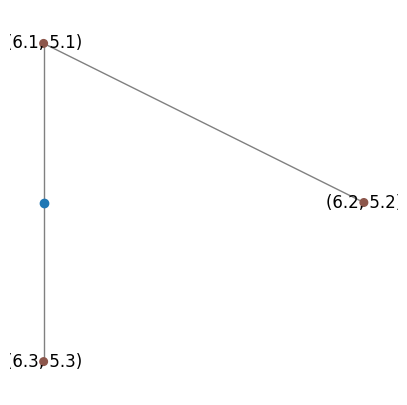

In [ ]:
from itertools import product

subgraph = nx.subgraph(switch_network_graph, [(6.1, 5.1), (6.2, 5.2), (6.3, 5.3)])


def align_graph(graph: nx.Graph) -> nx.Graph:

    pos = subgraph.nodes.data("pos")
    pos = {k: v for k, v in pos}

    pos_array = np.array([v for v in pos.values()])
    mean_pos = pos_array.mean(0)
    pos_array = np.sign(pos_array - mean_pos)

    if len(graph.nodes) == 3:
        for axis, value in product([0, 1], [-1, 1]):
            mask = pos_array[:, axis] == value
            if np.sum(mask) > 1:
                pos_array[mask, axis] = 0

    pos = {k: pos_array[idx] for idx, k in enumerate(pos.keys())}

    node_data = {node: graph.nodes.data()[node] for node in graph.nodes}
    for node in graph.nodes:
        node_data[node]["pos"] = pos[node]

    return graph


subgraph = align_graph(subgraph)


fig, ax = plt.subplots(figsize=(5, 5))
nx.draw(
    subgraph,
    pos,
    with_labels=True,
    node_color=dict(subgraph.nodes.data(data="node_color")).values(),
    edge_color="gray",
    node_size=30,
    ax=ax,
)

ax.scatter(*np.zeros(2))

{'node_color': '#aec7e8', 'pos': [5.0, -5.666666666666667], 'switch_id': (6, 5), 'switch_pos': (6, 5), 'rail_prev_node': (5, 5), 'actions': {(6.3, 5.3): [<RailEnvActions.MOVE_FORWARD: 2>, <RailEnvActions.MOVE_RIGHT: 3>], (6.2, 5.2): [<RailEnvActions.MOVE_FORWARD: 2>, <RailEnvActions.MOVE_LEFT: 1>]}}


[{(6.3, 5.3): [<RailEnvActions.MOVE_FORWARD: 2>,
   <RailEnvActions.MOVE_LEFT: 1>],
  (6.1, 5.1): [<RailEnvActions.STOP_MOVING: 4>,
   <RailEnvActions.STOP_MOVING: 4>],
  (6.2, 5.2): [<RailEnvActions.STOP_MOVING: 4>,
   <RailEnvActions.STOP_MOVING: 4>]},
 {(6.1, 5.1): [<RailEnvActions.MOVE_FORWARD: 2>,
   <RailEnvActions.MOVE_RIGHT: 3>],
  (6.3, 5.3): [<RailEnvActions.STOP_MOVING: 4>,
   <RailEnvActions.STOP_MOVING: 4>],
  (6.2, 5.2): [<RailEnvActions.STOP_MOVING: 4>,
   <RailEnvActions.STOP_MOVING: 4>]},
 {(6.1, 5.1): [<RailEnvActions.MOVE_FORWARD: 2>,
   <RailEnvActions.MOVE_LEFT: 1>],
  (6.3, 5.3): [<RailEnvActions.STOP_MOVING: 4>,
   <RailEnvActions.STOP_MOVING: 4>],
  (6.2, 5.2): [<RailEnvActions.STOP_MOVING: 4>,
   <RailEnvActions.STOP_MOVING: 4>]},
 {(6.2, 5.2): [<RailEnvActions.MOVE_FORWARD: 2>,
   <RailEnvActions.MOVE_RIGHT: 3>],
  (6.3, 5.3): [<RailEnvActions.STOP_MOVING: 4>,
   <RailEnvActions.STOP_MOVING: 4>],
  (6.1, 5.1): [<RailEnvActions.STOP_MOVING: 4>,
   <RailEnvActio

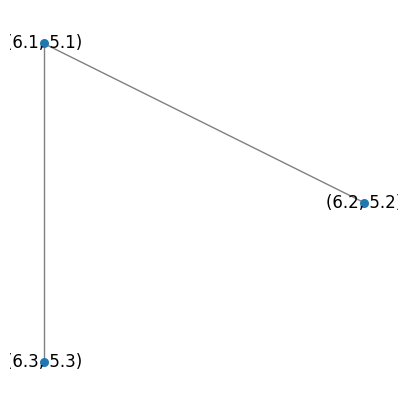

In [ ]:
def add_actions(graph: nx.Graph) -> nx.Graph:
    actions = {}

    for i, incoming in enumerate(graph.nodes):
        facing_index = (i + 2) % 4  # Opposite direction (facing)
        actions[incoming] = {"actions": {}}  # graph.nodes.data()[incoming]
        for j, target in enumerate(graph.nodes):
            if incoming == target or target not in graph.neighbors(incoming):
                continue  # Cannot go back to where you came from
            relative = (j - facing_index) % 4
            action = [RailEnvActions.MOVE_FORWARD]
            if relative == 0:
                action.append(RailEnvActions.MOVE_FORWARD)
            elif relative == 1:
                action.append(RailEnvActions.MOVE_RIGHT)
            elif relative == 3:
                action.append(RailEnvActions.MOVE_LEFT)
            else:
                action = "invalid"  # Shouldn't occur
            actions[incoming]["actions"][target] = action

    nx.set_node_attributes(G=graph, values=actions)
    return graph


subgraph = nx.subgraph(switch_network_graph, [(6.1, 5.1), (6.2, 5.2), (6.3, 5.3)])
subgraph = add_actions(nx.Graph(subgraph))
print(subgraph.nodes.data()[(6.1, 5.1)])

fig, ax = plt.subplots(figsize=(5, 5))
nx.draw(
    subgraph,
    subgraph.nodes.data("pos"),
    with_labels=True,
    edge_color="gray",
    node_size=30,
    ax=ax,
)


# aggregate actions
def build_rail_action_map(graph: nx.Graph) -> List[Dict[Any, List[RailEnvActions]]]:
    actions = []
    for node in graph.nodes:
        for a in graph.nodes.data("actions")[node].values():
            action = {}
            action[node] = a
            for node2 in graph.nodes:
                if node2 == node:
                    continue
                action[node2] = [RailEnvActions.STOP_MOVING, RailEnvActions.STOP_MOVING]
            actions.append(action)
    return actions


build_rail_action_map(subgraph)

In [ ]:
actions = [
    {
        **{
            n: [RailEnvActions.STOP_MOVING, RailEnvActions.STOP_MOVING]
            for n in subgraph.nodes
            if n != node
        },
        node: a,
    }
    for node in subgraph.nodes
    for a in subgraph.nodes[node]["actions"].values()
]

In [ ]:
G = nx.Graph()
G.add_nodes_from([(4, {"color": "red"}), (5, {"color": "green"})])

red
green
